In [596]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import astropy.units as u
from matplotlib.colors import LogNorm


In [597]:
def read_image_as_map(image_path, image_size=1.0*u.arcmin, peak_flux=1.0*u.Jy,invert=False):
    """
    Read an image file and return it as a 2D numpy array (sky brightness map).
    
    Parameters
    ----------
    image_path : str
        Path to the image file.
    
    Returns
    -------
    sky_map : ndarray, shape (npix, npix)
        2D array representing the sky brightness map.
    """
    
    # Open the image file
    img = Image.open(image_path)
    
    # Convert to grayscale and then to a numpy array
    img_gray = img.convert('L')

    # crop to a square image
    width, height = img_gray.size
    min_dim = min(width, height)
    left = (width - min_dim) / 2
    top = (height - min_dim) / 2
    right = (width + min_dim) / 2
    bottom = (height + min_dim) / 2
    img_gray = img_gray.crop((left, top, right, bottom))

    npix = min_dim

    pixel_scale = (image_size / min_dim).to(u.rad).value  # radians per pixel
    

    if invert:
        img_gray = ImageOps.invert(img_gray)
    sky_map = np.array(img_gray)

    # Make sky map in Jy/steradian
    sky_map = (sky_map / 255.0) * peak_flux.to(u.Jy).value / (pixel_scale**2)  # Jy/steradian
    
    return sky_map, pixel_scale




def gaussian_beam(pixel_scale, npix,fwhm=30*u.arcsec):
    """
    Create a 2D Gaussian beam.
    
    Parameters
    ----------
    fwhm : float
        Full width at half maximum of the Gaussian beam (in arcseconds).
    
    Returns
    -------
    beam : ndarray, shape (npix, npix)
        2D array representing the Gaussian beam.
    """
    x = np.linspace(-npix/2, npix/2, npix)
    y = np.linspace(-npix/2, npix/2, npix)
    X, Y = np.meshgrid(x, y)
    # if pixel_scale is quantity, convert to value in radians
    if isinstance(pixel_scale, u.Quantity):
        pixel_scale = pixel_scale.to(u.rad).value
    
    sigma = (fwhm.to(u.rad).value / pixel_scale) / (2 * np.sqrt(2 * np.log(2)))  # convert FWHM to sigma
    print(sigma)
    beam = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    
    return beam

In [598]:
def antenna_example_ew_line(spacing=400*u.m,nant=8):
    """
    Example of a two-element interferometer with a line of sight along the x-axis.
    
    Parameters
    ----------
    spacing : float
        Spacing between the two antennas (in meters).
    nant : int
        Number of antennas.

    Returns
    -------
    antenna_positions : ndarray, shape (2, 3)
        Positions of the two antennas in 3D space (x, y, z).
    """
    # Convert spacing to meters
    spacing_m = spacing.to(u.m).value
    
    # Antenna positions:
    antenna_positions = np.zeros((nant, 3))
    for i in range(nant):
        antenna_positions[i] = [i * spacing_m, 0, 0]
    return antenna_positions

def antenna_example_pseudo_VLA(config='A'):
    if config=='A':
        Ndist = [0,436,1433,2874,4709,6906,9443,12302,15470,18935]
        Wdist = [484,1589,3188,5230,7644,10420,13660,17270,21250]
        Edist = [484,1589,3188,5230,7644,10420,13660,17270,21250]
    elif config=='B':
        Ndist=[0,135,436,872,1433,2180,3121,4255,5582]
        Edist=[147,484,968,1589,2495,3606,4922,6443]
        Wdist=[147,484,968,1589,2495,3606,4922,6443]
    elif config=='C':
        Ndist=[1,54,134,266,436,644,872,1120,1140,1754]
        Edist=[49,147,294,484,727,1021,1378,1800]
        Wdist=[49,147,294,484,727,1021,1378,1800]
    elif config=='D':
        Ndist=[1,54,94,134,194,266,347,436,527]
        Edist=[24,73,147,242,358,484,631]
        Wdist=[24,73,147,242,358,484,631]
    else:
        raise ValueError("Invalid configuration. Choose from 'A', 'B', 'C', or 'D'.")
    # North arm is heading 355 deg
    # East arm is heading 115 deg
    # West arm is heading 236 deg
    N_xy = np.array([[np.sin(np.deg2rad(355)), np.cos(np.deg2rad(355))] for d in Ndist])
    E_xy = np.array([[np.sin(np.deg2rad(115)), np.cos(np.deg2rad(115))] for d in Edist])
    W_xy = np.array([[np.sin(np.deg2rad(236)), np.cos(np.deg2rad(236))] for d in Wdist])
    N_xy = N_xy * np.array(Ndist)[:, np.newaxis]
    E_xy = E_xy * np.array(Edist)[:, np.newaxis]
    W_xy = W_xy * np.array(Wdist)[:, np.newaxis]
    antenna_positions = np.vstack((N_xy, E_xy, W_xy))

    return antenna_positions


def antenna_example_gaussian_random(nant, dispersion=300*u.m,seed=0x3606A562):
    """
    Example of a random distribution of antennas with a Gaussian distribution of baselines.
    
    Parameters
    ----------
    nant : int
        Number of antennas.
    dispersion : float
        Standard deviation of the Gaussian distribution of baselines (in meters).
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    antenna_positions : ndarray, shape (nant, 3)
        Positions of the antennas in 3D space (x, y, z).
    """
    # Store the seed to avoid affecting other results.
    store_seed=np.random.seed()
    np.random.seed(seed)
    # Generate random positions in 2D plane
    x = np.random.normal(0, dispersion.to(u.m).value, max(nant,1024))[:nant]
    y = np.random.normal(0, dispersion.to(u.m).value, max(nant,1024))[:nant]
    np.random.seed(store_seed)
    # Stack into a single array and add z=0 for 2D plane
    antenna_positions = np.vstack((x, y, np.zeros(nant))).T
    
    return antenna_positions



In [599]:

def make_uv_coverage(
    antenna_positions,
    pixel_scale,
    image_width,
    declination,
    hour_angles,
    wavelength,
):
    """
    Calculate the Fourier u-v grid and Earth-rotation u-v tracks.

    Parameters
    ----------
    antenna_positions : array_like, shape (N_ant, 2) or (N_ant, 3)
        Antenna positions in metres in a local ENU coordinate system:
        [East, North] or [East, North, Up].

    pixel_scale : float
        Image pixel scale in radians/pixel.

    image_width : int
        Number of pixels along each image dimension.

    declination : float
        Source declination in radians.

    hour_angles : array_like
        Hour angles at which to sample the observation, hours after the meridian.
        Positive H corresponds to hour angle west of the meridian.

    wavelength : float
        Observing wavelength in metres.

    Returns
    -------
    u_grid, v_grid : 2D ndarray
        Fourier-plane coordinates in wavelengths.

    uv_tracks : ndarray, shape (N_baselines, N_times, 2)
        u,v coordinates for each baseline and time, in wavelengths.

    baselines : ndarray, shape (N_baselines, 3)
        Physical baseline vectors [E, N, U] in metres.

    """

    antenna_positions = np.asarray(antenna_positions, dtype=float)

    if antenna_positions.ndim != 2:
        raise ValueError("antenna_positions must be a 2D array")

    if antenna_positions.shape[1] == 2:
        # Add zero vertical coordinate
        antenna_positions = np.column_stack(
            [antenna_positions, np.zeros(len(antenna_positions))]
        )

    if antenna_positions.shape[1] != 3:
        raise ValueError(
            "antenna_positions must have shape (N,2) or (N,3)"
        )

    hour_angles = (np.asarray(hour_angles, dtype=float)*u.hourangle).to(u.radian).value

    # ------------------------------------------------------------
    # Fourier-plane grid
    # ------------------------------------------------------------

    # np.fft.fftfreq gives cycles per radian when the sample spacing
    # is in radians. These are therefore spatial frequencies in
    # wavelengths (u,v).
    freq = np.fft.fftfreq(
        image_width,
        d=pixel_scale
    )

    u_grid, v_grid = np.meshgrid(
        np.fft.fftshift(freq),
        np.fft.fftshift(freq)
    )

    # ------------------------------------------------------------
    # Form all unique antenna pairs
    # ------------------------------------------------------------

    baselines = []

    n_ant = len(antenna_positions)

    for i in range(n_ant):
        for j in range(i + 1, n_ant):
            # Baseline from antenna i -> antenna j
            baseline = antenna_positions[j] - antenna_positions[i]
            baselines.append(baseline)

    baselines = np.asarray(baselines)

    # ------------------------------------------------------------
    # Project baselines into u,v,w
    # ------------------------------------------------------------

    E = baselines[:, 0][:, None]
    N = baselines[:, 1][:, None]
    U = baselines[:, 2][:, None]

    H = hour_angles[None, :]

    sinH = np.sin(H)
    cosH = np.cos(H)

    sind = np.sin(declination)
    cosd = np.cos(declination)

    # Baseline components in wavelengths
    _u = (E * sinH + N * cosH) / wavelength

    _v = (
        -E * sind * cosH
        + N * sind * sinH
        + U * cosd
    ) / wavelength

    _w = (
        E * cosd * cosH
        - N * cosd * sinH
        + U * sind
    ) / wavelength

    uv_tracks = np.stack([_u, _v], axis=-1)

    return u_grid, v_grid, uv_tracks, baselines, w

In [600]:

def make_uv_data(image, u_tracks, v_tracks, pixel_scale):
    """
    Fourier transform an image and sample it at specified u-v tracks.

    The supplied u-v tracks represent the measured visibilities. Because
    the sky brightness is real-valued, the conjugate visibility

        V(-u, -v) = V*(u, v)

    is also included automatically in the sampled Fourier plane.

    Parameters
    ----------
    image : ndarray, shape (N, N)
        Sky brightness distribution in Jy/sr.
        The image is assumed to be centred on the middle pixel.

    u_tracks, v_tracks : ndarray
        U-v coordinates of the measured points, in wavelengths.
        These should have the same shape, e.g. (n_baselines, n_times).

    pixel_scale : float
        Image pixel scale in radians/pixel.

    Returns
    -------
    _u : ndarray
        1-D u coordinate grid, in wavelengths.

    _v : ndarray
        1-D v coordinate grid, in wavelengths.

    V_full : ndarray
        Full Fourier transform of the image.

    V_masked : ndarray
        Fourier plane containing the measured visibilities and their
        conjugate points. Unsampled pixels are zero.

    mask : ndarray of bool
        Sampling mask. True for both measured and conjugate points.

    """

    N = image.shape[0]

    if image.shape[1] != N:
        raise ValueError("image must be square")

    if u_tracks.shape != v_tracks.shape:
        raise ValueError("u_tracks and v_tracks must have the same shape")

    # ------------------------------------------------------------------
    # Fourier transform of the image
    # ------------------------------------------------------------------

    # Pixel solid angle. This converts Jy/sr -> Jy when integrating
    # the brightness distribution.
    dOmega = pixel_scale**2

    V_full = np.fft.fftshift(
        np.fft.fft2(
            np.fft.ifftshift(image)
        )
    ) * dOmega

    # ------------------------------------------------------------------
    # Fourier-plane coordinates
    # ------------------------------------------------------------------

    _u = np.fft.fftshift(
        np.fft.fftfreq(N, d=pixel_scale)
    )
    _v = np.fft.fftshift(
        np.fft.fftfreq(N, d=pixel_scale)
    )

    du = _u[1] - _u[0]
    dv = _v[1] - _v[0]

    # ------------------------------------------------------------------
    # Convert physical u-v coordinates to Fourier-grid indices
    # ------------------------------------------------------------------

    def uv_to_indices(u_points, v_points):

        iu = np.rint((u_points - _u[0]) / du).astype(int)
        iv = np.rint((v_points - _v[0]) / dv).astype(int)

        valid = (
            (iu >= 0) & (iu < N) &
            (iv >= 0) & (iv < N)
        )

        return iu, iv, valid

    # Measured points
    iu, iv, valid = uv_to_indices(u_tracks, v_tracks)

    # ------------------------------------------------------------------
    # Construct the sampling mask
    # ------------------------------------------------------------------

    mask = np.zeros((N, N), dtype=bool)

    # Add the actual measured u-v points
    mask[iv[valid], iu[valid]] = True

    # Add the conjugate points:
    #
    #       V(-u,-v) = V*(u,v)
    #
    # These are implied by the real-valued sky brightness.
    iu_conj, iv_conj, valid_conj = uv_to_indices(
        -u_tracks, -v_tracks
    )

    mask[iv_conj[valid_conj], iu_conj[valid_conj]] = True

    # ------------------------------------------------------------------
    # Apply the mask to the full visibility plane
    # ------------------------------------------------------------------

    V_masked = np.zeros_like(V_full)

    V_masked[mask] = V_full[mask]

    return _u, _v, V_full, V_masked, mask

434.85276174746576


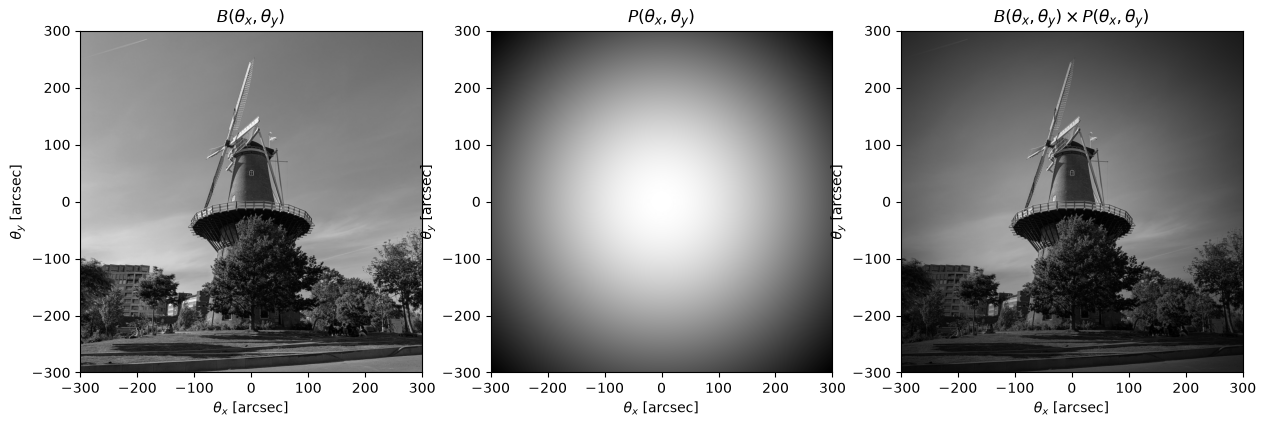

In [601]:
sky_brightness_map, pixel_scale = read_image_as_map("images/windmill.jpg", invert=False, image_size=10.0*u.arcmin, peak_flux=1.0*u.Jy)

image_halfwidth=(pixel_scale*sky_brightness_map.shape[0]*u.rad).to(u.arcsec).value/2

wavelength=0.21
dish_diameter=25.0
beamwidth=(1.15*wavelength/dish_diameter)*u.rad

beamwidth=10*u.arcmin

primary_beam = gaussian_beam(pixel_scale=pixel_scale, npix=sky_brightness_map.shape[0], fwhm=beamwidth)

plt.figure(figsize=(15, 5))
plt.subplot(1,3,1)
plt.title(r"$B(\theta_x,\theta_y)$")
plt.imshow(sky_brightness_map, cmap='gray',extent=[-image_halfwidth, image_halfwidth, -image_halfwidth, image_halfwidth])
plt.xlabel(r"$\theta_x$ [arcsec]")
plt.ylabel(r"$\theta_y$ [arcsec]")
plt.subplot(1,3,2)
plt.title(r"$P(\theta_x,\theta_y)$")
plt.imshow(primary_beam, cmap='gray',extent=[-image_halfwidth, image_halfwidth, -image_halfwidth, image_halfwidth])
plt.xlabel(r"$\theta_x$ [arcsec]")
plt.ylabel(r"$\theta_y$ [arcsec]")
plt.subplot(1,3,3)
plt.title(r"$B(\theta_x,\theta_y) \times P(\theta_x,\theta_y)$")
plt.imshow(sky_brightness_map * primary_beam, cmap='gray',extent=[-image_halfwidth, image_halfwidth, -image_halfwidth, image_halfwidth])
plt.xlabel(r"$\theta_x$ [arcsec]")
plt.ylabel(r"$\theta_y$ [arcsec]")
plt.show()


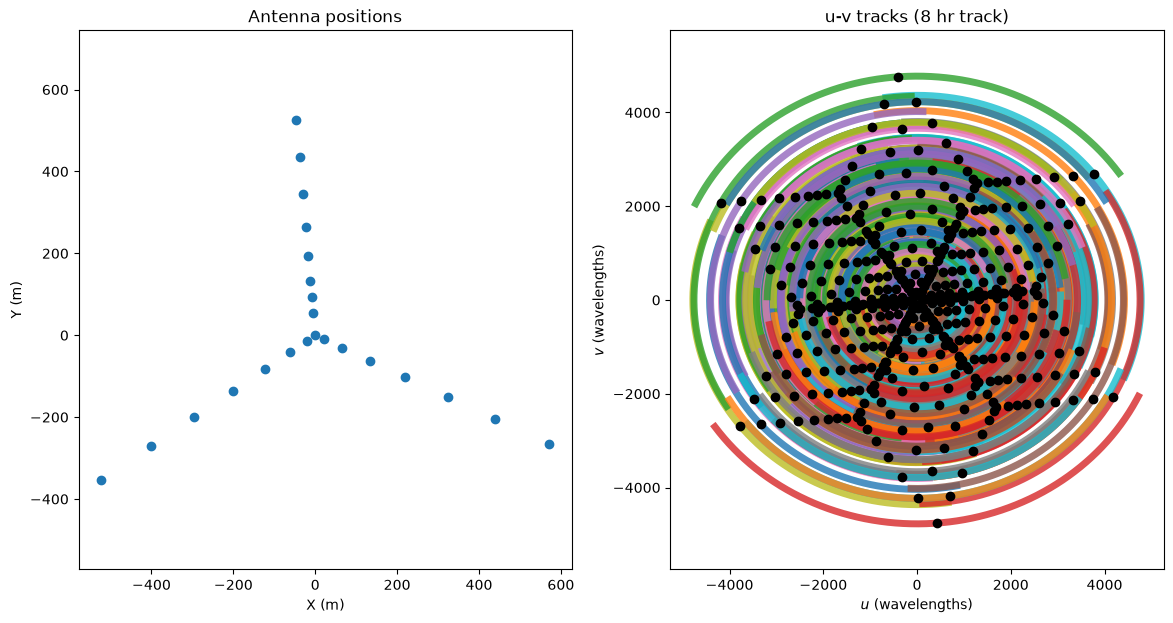

In [606]:
antenna = antenna_example_pseudo_VLA(config='D')
#antenna = antenna_example_gaussian_random(nant=20, dispersion=1000*u.m)

tspan=8
u_grid, v_grid, uv_tracks, baselines, w = make_uv_coverage(
    antenna_positions=antenna,
    pixel_scale=pixel_scale,
    image_width=sky_brightness_map.shape[0],
    declination=20.0,
    hour_angles=np.linspace(-tspan/2, tspan/2, 1000),
    wavelength=0.21,  # 21 cm
)


plt.figure(figsize=(14, 7))
plt.subplot(1,2,1)
plt.title("Antenna positions")
plt.plot(antenna[:, 0], antenna[:, 1], "o")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.axis("equal")


plt.subplot(1,2,2)
plt.title(f"u-v tracks ({tspan} hr track)")
mid_time=int(len(uv_tracks[0])/2)
for track in uv_tracks:
    plt.plot(track[:, 0], track[:, 1], "-",lw=5,alpha=0.8)

    # Conjugate track
    plt.plot(-track[:, 0], -track[:, 1], "-",lw=5,alpha=0.8)
    plt.plot(track[mid_time, 0], track[mid_time, 1], "o", color="k",zorder=4)
    plt.plot(-track[mid_time, 0], -track[mid_time, 1], "o", color="k",zorder=4)

plt.xlabel("$u$ (wavelengths)")
plt.ylabel("$v$ (wavelengths)")
plt.axis("equal")
plt.show()

/var/folders/4y/fktqs4zs0sd80jg4w42h8fhr0000gp/T/ipykernel_65952/1378924961.py:11: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(V_masked)), cmap='gray',extent=[_u[0], _u[-1], _v[0], _v[-1]])


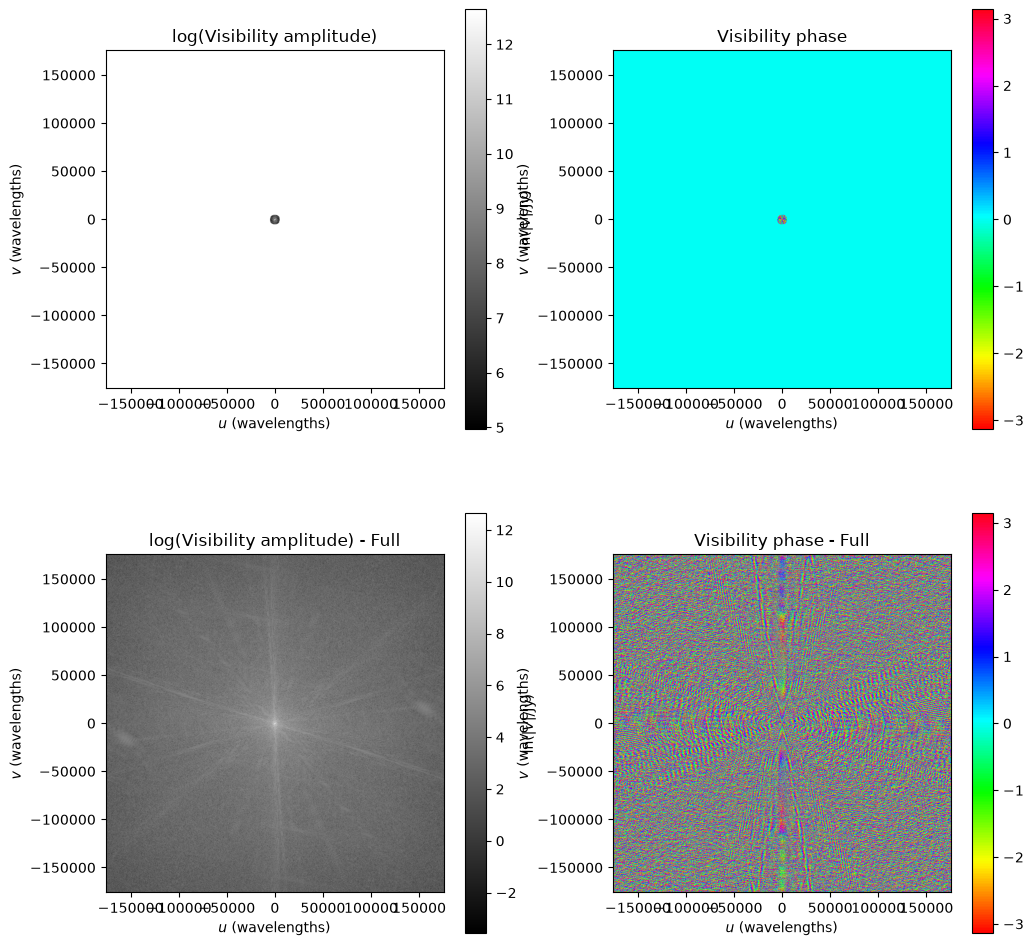

In [607]:
_u,_v,V_full,V_masked,mask = make_uv_data(sky_brightness_map*primary_beam, uv_tracks[:, :, 0], uv_tracks[:, :, 1], pixel_scale)




# Show the u-v plane coverage and the masked visibility plane in phase and intensity
plt.figure(figsize=(12, 12))

plt.subplot(2,2,1)
plt.title("log(Visibility amplitude)")
plt.imshow(np.log(np.abs(V_masked)), cmap='gray',extent=[_u[0], _u[-1], _v[0], _v[-1]])
plt.xlabel("$u$ (wavelengths)")
plt.ylabel("$v$ (wavelengths)")
colorbar = plt.colorbar()
colorbar.set_label(r"$\ln(|V|/\mathrm{Jy})$")

plt.subplot(2,2,2)
plt.title("Visibility phase")
plt.imshow(np.angle(V_masked), cmap='hsv',extent=[_u[0], _u[-1], _v[0], _v[-1]])
plt.xlabel("$u$ (wavelengths)")
plt.ylabel("$v$ (wavelengths)")
plt.colorbar()

plt.subplot(2,2,3)
plt.title("log(Visibility amplitude) - Full")
plt.imshow(np.log(np.abs(V_full)), cmap='gray',extent=[_u[0], _u[-1], _v[0], _v[-1]])
plt.xlabel("$u$ (wavelengths)")
plt.ylabel("$v$ (wavelengths)")
colorbar = plt.colorbar()
colorbar.set_label(r"$\ln(|V|/\mathrm{Jy})$")

plt.subplot(2,2,4)
plt.title("Visibility phase - Full")
plt.imshow(np.angle(V_full), cmap='hsv',extent=[_u[0], _u[-1], _v[0], _v[-1]])
plt.xlabel("$u$ (wavelengths)")
plt.ylabel("$v$ (wavelengths)")
plt.colorbar()
plt.show()

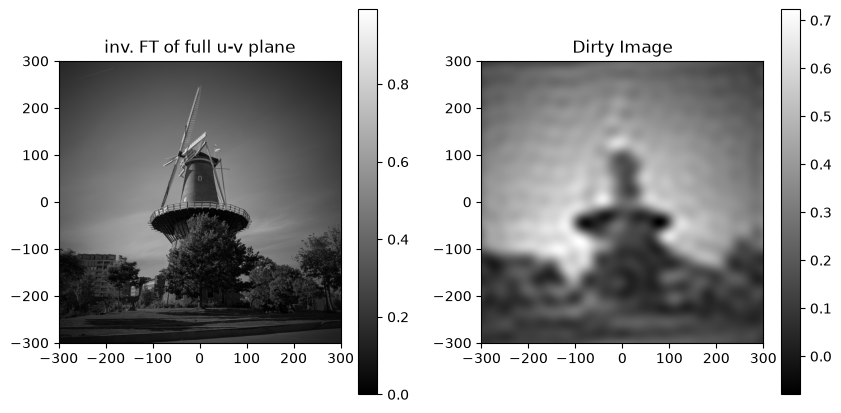

In [608]:
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
reconstructed_image = np.fft.fftshift(
    np.fft.ifft2(
        np.fft.ifftshift(V_full)
    )
).real
plt.title("inv. FT of full u-v plane")
plt.imshow(reconstructed_image, cmap='gray',extent=[-image_halfwidth, image_halfwidth, -image_halfwidth, image_halfwidth])
plt.colorbar()

dirty_image = np.fft.fftshift(
    np.fft.ifft2(
        np.fft.ifftshift(V_masked)
    )
).real
plt.subplot(1,2,2)
plt.title("Dirty Image")
plt.imshow(dirty_image, cmap='gray',extent=[-image_halfwidth, image_halfwidth, -image_halfwidth, image_halfwidth])
plt.colorbar()
plt.show()

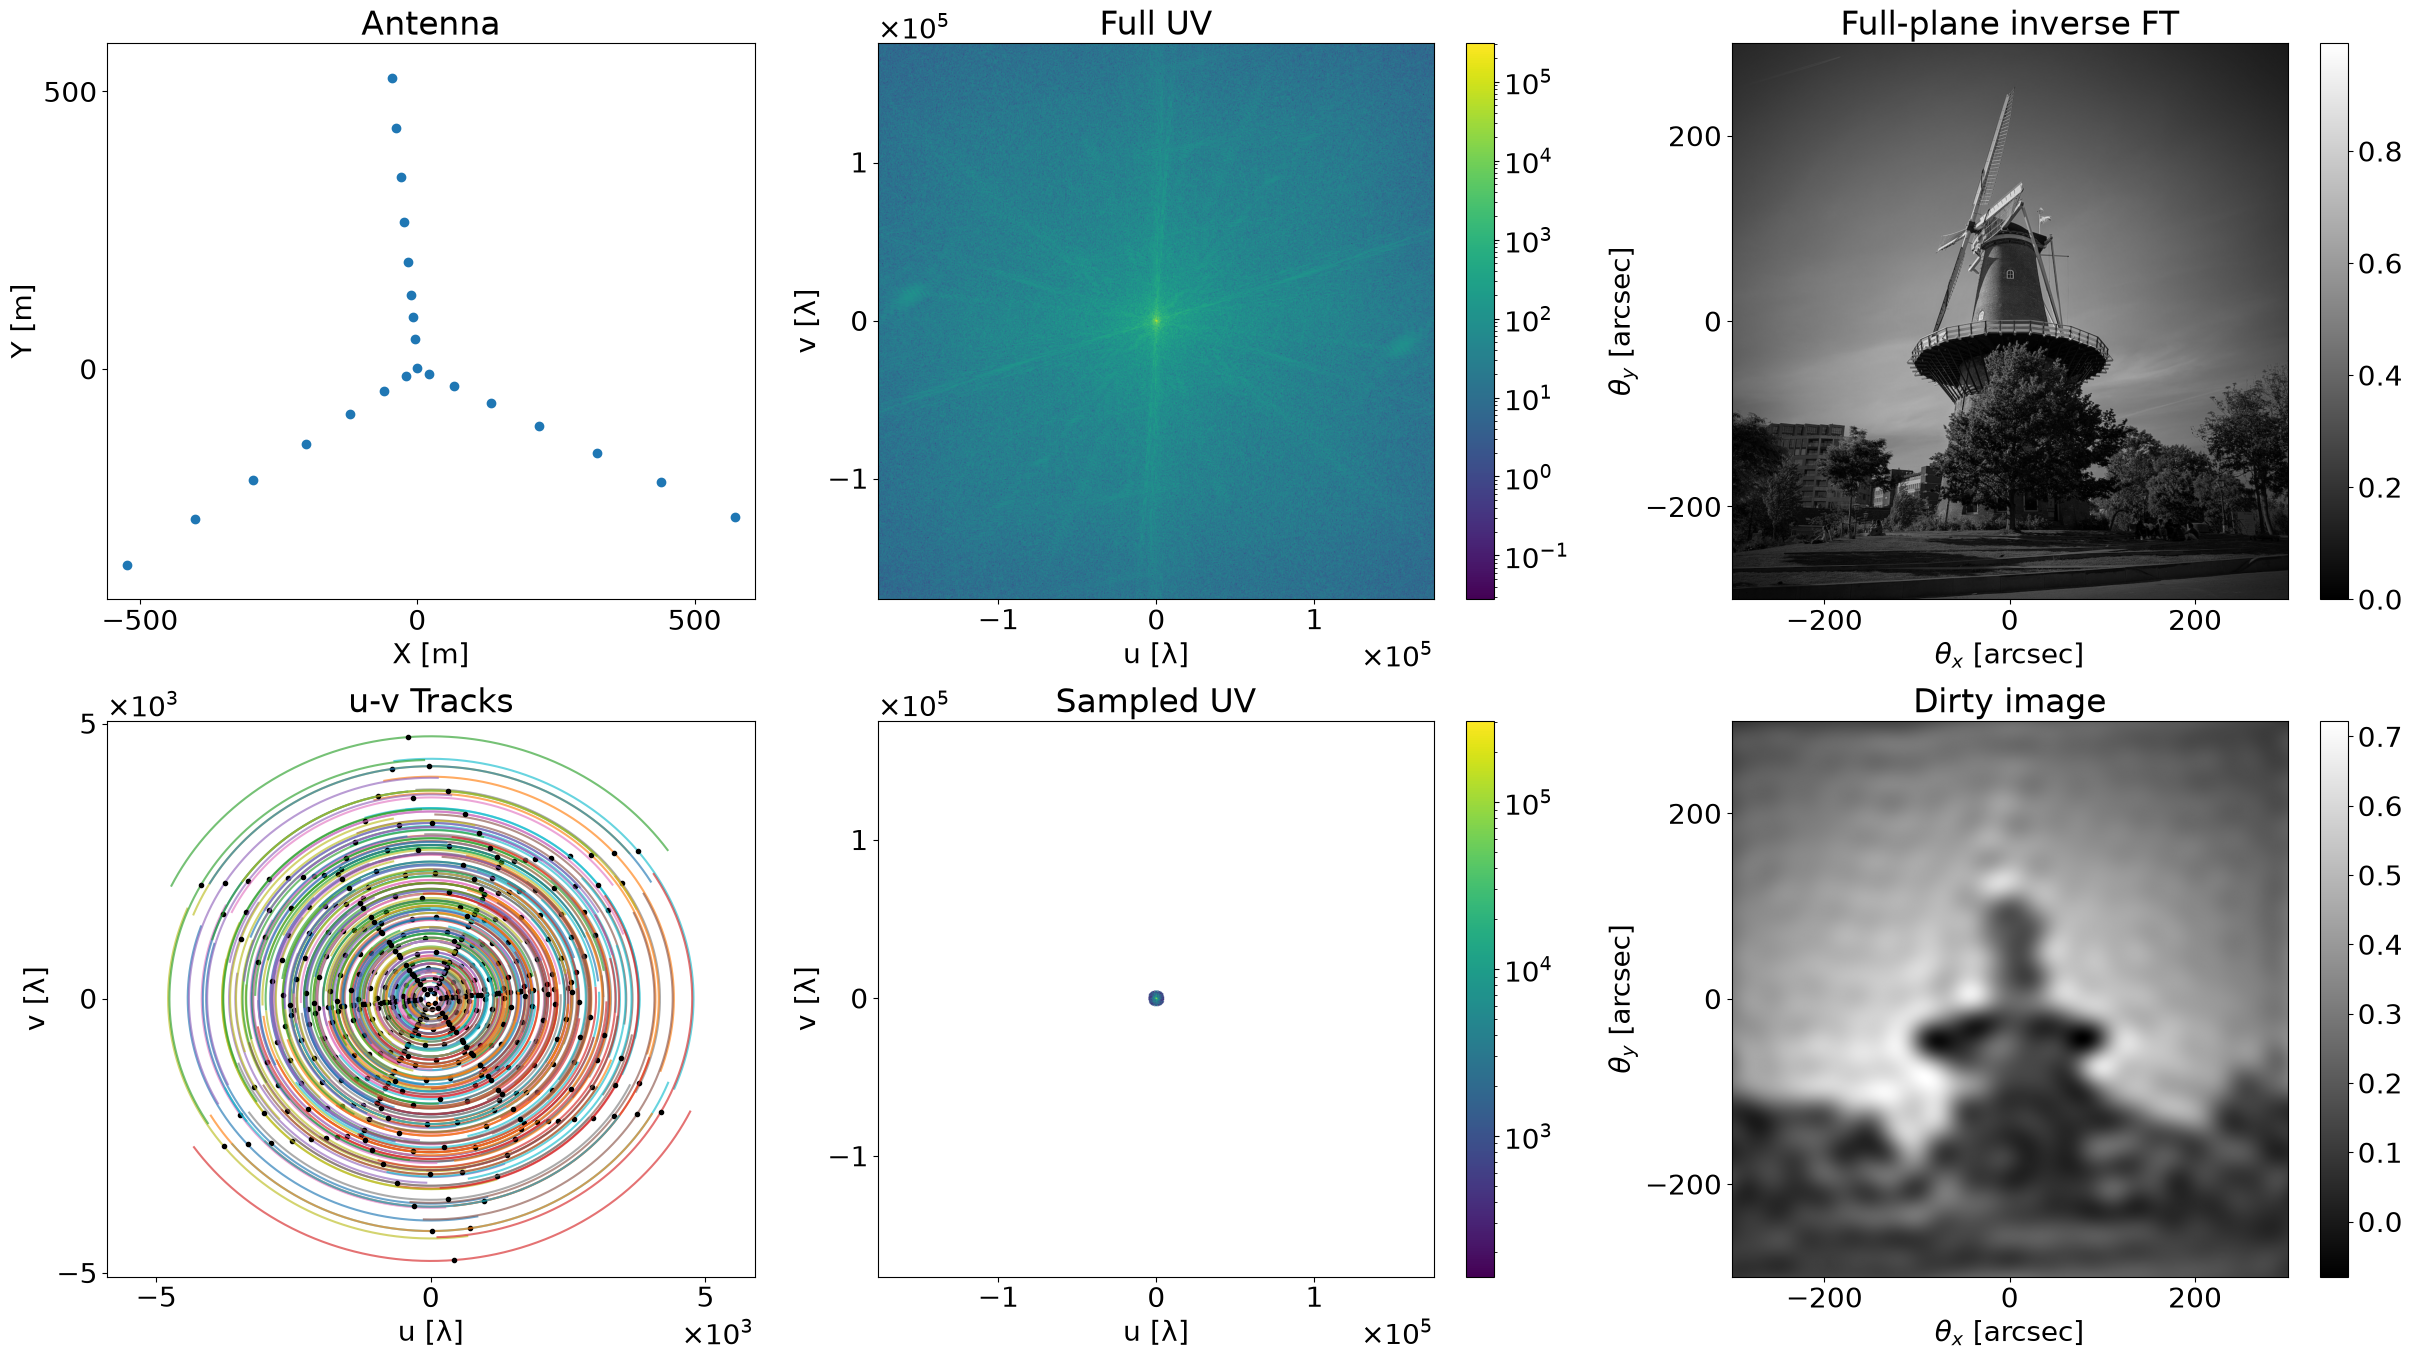

In [609]:
# 2 rows x 3 columns:
# Antenna | Full UV | Full-plane inverse FT
# Tracks  | Sampled UV | Dirty image

reconstructed_image = np.fft.fftshift(
    np.fft.ifft2(np.fft.ifftshift(V_full))
).real
dirty_image = np.fft.fftshift(
    np.fft.ifft2(np.fft.ifftshift(V_masked))
).real

# Fourfold font scaling for lecture-slide readability, scoped to this figure.
with plt.rc_context({"font.size": 20}):
    fig, axes = plt.subplots(
        2, 3, figsize=(24, 13.5), constrained_layout=True
    )
    for ax in axes.flat:
        ax.locator_params(axis="both", nbins=3)

    # Antenna layout
    ax = axes[0, 0]
    ax.set_title("Antenna")
    ax.plot(antenna[:, 0], antenna[:, 1], "o")
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.axis("equal")

    # Full UV-plane visibility amplitude
    ax = axes[0, 1]
    image = ax.imshow(
        np.abs(V_full),
        cmap="viridis",
        origin="lower",
        extent=[_u[0], _u[-1], _v[0], _v[-1]],norm=LogNorm()
    )
    ax.set_title("Full UV")
    ax.set_xlabel("u [λ]")
    ax.set_ylabel("v [λ]")
    ax.ticklabel_format(axis="both", style="sci", scilimits=(0, 0), useMathText=True)
    fig.colorbar(image, ax=ax)

    # Inverse Fourier transform of the full UV plane
    ax = axes[0, 2]
    image = ax.imshow(
        reconstructed_image,
        cmap="gray",
        extent=[-image_halfwidth, image_halfwidth, -image_halfwidth, image_halfwidth],
    )
    ax.set_title("Full-plane inverse FT")
    ax.set_xlabel(r"$\theta_x$ [arcsec]")
    ax.set_ylabel(r"$\theta_y$ [arcsec]")
    fig.colorbar(image, ax=ax)

    # UV tracks, including conjugate tracks for a real-valued sky image
    ax = axes[1, 0]
    ax.set_title("u-v Tracks")
    mid_time = len(uv_tracks[0]) // 2
    for track in uv_tracks:
        ax.plot(track[:, 0], track[:, 1], "-", lw=1.5, alpha=0.65)
        ax.plot(-track[:, 0], -track[:, 1], "-", lw=1.5, alpha=0.65)
        ax.plot(track[mid_time, 0], track[mid_time, 1], "o", color="k", ms=3)
        ax.plot(-track[mid_time, 0], -track[mid_time, 1], "o", color="k", ms=3)
    ax.set_xlabel("u [λ]")
    ax.set_ylabel("v [λ]")
    ax.ticklabel_format(axis="both", style="sci", scilimits=(0, 0), useMathText=True)
    ax.axis("equal")

    # Sampled (masked) UV-plane visibility amplitude
    ax = axes[1, 1]
  
    image = ax.imshow(
        np.abs(V_masked),
        cmap="viridis",
        origin="lower",
        extent=[_u[0], _u[-1], _v[0], _v[-1]],
        norm=LogNorm()
    )
    ax.set_title("Sampled UV")
    ax.set_xlabel("u [λ]")
    ax.set_ylabel("v [λ]")
    ax.ticklabel_format(axis="both", style="sci", scilimits=(0, 0), useMathText=True)
    fig.colorbar(image, ax=ax)

    # Dirty image from the sampled UV plane
    ax = axes[1, 2]
    image = ax.imshow(
        dirty_image,
        cmap="gray",
        extent=[-image_halfwidth, image_halfwidth, -image_halfwidth, image_halfwidth],
    )
    ax.set_title("Dirty image")
    ax.set_xlabel(r"$\theta_x$ [arcsec]")
    ax.set_ylabel(r"$\theta_y$ [arcsec]")
    fig.colorbar(image, ax=ax)

    plt.show()